# e1 - setup do pacote

Carrega o pacote (`pacote-e1-2026-09-13`), mostra o padrão certo de comparação entre plataformas
(posição dentro da plataforma, nunca média com média) e um gráfico de exemplo. A análise é de vocês:
as sete perguntas sugeridas estão no `README.md` do pacote, e no fim deste caderno tem o mapa
pergunta -> tabela -> gráfico.


## 1. onde está o pacote

No Colab: monta o Drive e aponta `PACOTE` pra pasta descompactada. Rodando local, aponta pra `datalake/pacote/...`.


In [1]:
import os
import sys

NO_COLAB = "google.colab" in sys.modules
if NO_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PACOTE = "/content/drive/MyDrive/eps7008-e1/pacote-e1-2026-09-13"  # ajuste pro caminho da pasta compartilhada
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "duckdb"], check=True)
else:
    PACOTE = "../datalake/pacote/pacote-e1-2026-09-13"

assert os.path.exists(f"{PACOTE}/VERSAO.txt"), "pacote não encontrado: ajuste PACOTE"
print(open(f"{PACOTE}/VERSAO.txt").read())


pacote: pacote-e1-2026-09-13
gerado em: 2026-09-13 16:19 -03
commit: d584668 (docs: readme do repo, fontes e reprodutibilidade do zero)
checks: 26/26 checks ok
fontes: imdb e tmdb coletados em 2026-09-13; letterboxd (kaggle/freeth) dump de 2023-10-10; ml-32m gerado em 2023-10-13; ml-1m janela 2000-2003



In [2]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


## 2. as tabelas como views do duckdb

O duckdb consulta o parquet direto, sem carregar nada. `con.sql("...").df()` devolve um dataframe quando precisar do pandas.


In [3]:
con = duckdb.connect()
for camada in ("silver", "gold"):
    for arquivo in sorted(os.listdir(f"{PACOTE}/{camada}")):
        nome = arquivo.removesuffix(".parquet")
        con.sql(f"create or replace view {nome} as select * from '{PACOTE}/{camada}/{arquivo}'")
con.sql("select view_name from duckdb_views() where not internal order by 1").df()


,view_name
0,arbitragem_tmdb
1,classificacao_br
2,classificacao_br_decada
3,cobertura_canonicidade
4,cobertura_decada_faixa
5,cobertura_ponte
6,cobertura_ponte_decada
7,cobertura_ponte_faixa
8,cobertura_tmdb
9,cobertura_top200_decada


In [4]:
con.sql("select * from dim_titulo limit 5").df()


,tconst,titulo,titulo_original,ano,decada,duracao,generos,pct_votos_decada,n_paises,pais_unico,tem_us
0,tt0057507,The Skydivers,The Skydivers,1963,1960,75,"Drama,Sport",0.000000,1,US,True
1,tt0055052,The End of Summer,Kohayagawa-ke no aki,1961,1960,103,Drama,0.000000,1,JP,False
2,tt0059250,The Hallelujah Trail,The Hallelujah Trail,1965,1960,165,"Comedy,Western",0.003150,1,US,True
3,tt0057318,A Dog's Life,Mondo cane,1962,1960,108,"Documentary,Horror",0.004724,1,IT,False
4,tt0064888,The House That Screamed,La residencia,1969,1960,94,"Horror,Mystery,Thriller",0.006299,1,ES,False


In [5]:
con.sql("""
select plataforma, count(*) as titulos, round(avg(nota), 2) as media_bruta,
  min(escala_min) as escala_de, max(escala_max) as escala_ate, median(n_votos) as votos_mediana
from fato_notas group by 1 order by 1
""").df()


,plataforma,titulos,media_bruta,escala_de,escala_ate,votos_mediana
0,imdb,17810,6.51,1.0,10.0,16013.0
1,letterboxd,17547,3.02,0.5,5.0,319.0
2,ml32,16877,3.21,0.5,5.0,207.0
3,tmdb,17795,6.48,0.0,10.0,352.0


## 3. o padrão: posição dentro da plataforma

`gold/notas_normalizadas` já traz `nota_z` e `nota_pct`, calculados sobre as linhas com `n_votos >= 30`.
Se precisar recalcular em outro recorte (só um país, só uma década), a regra é esta e nada mais:


In [6]:
def normalizar(df, grupo="plataforma", nota="nota"):
    """z-score e percentil da nota dentro de cada grupo; é o que gold/notas_normalizadas faz em sql"""
    g = df.groupby(grupo)[nota]
    return df.assign(
        nota_z=(df[nota] - g.transform("mean")) / g.transform("std"),
        nota_pct=g.rank(pct=True),
    )


fato = con.sql("select * from fato_notas where n_votos >= 30").df()
normalizado = normalizar(fato)

# confere que bate com o gold
gold = con.sql("select tconst, plataforma, nota_z as nota_z_gold from notas_normalizadas").df()
conferencia = normalizado.merge(gold, on=["tconst", "plataforma"])
print("maior diferença pro gold:", (conferencia.nota_z - conferencia.nota_z_gold).abs().max())


maior diferença pro gold: 7.105427357601002e-14


## 4. um gráfico: por que a média engana

Esquerda: média bruta por plataforma e década. Escalas diferentes (1-10, 0-10, 0,5-5), não diz nada.
Direita: média de `nota_z` por plataforma e década, **só no quartil superior de `pct_votos_decada`** -
o cânone de cada década, onde a cobertura do Letterboxd é plana e as populações são comparáveis.
O controle pelo quartil é o que separa "o Letterboxd gosta de filme antigo" de "o frame dos anos 1930 é só cânone".


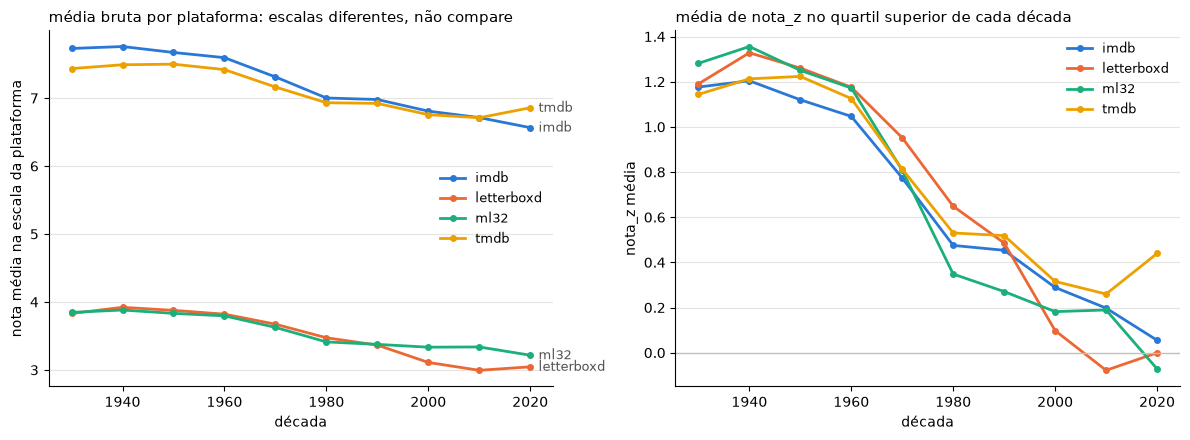

In [7]:
serie = con.sql("""
select d.decada, n.plataforma, avg(n.nota) as media_bruta, avg(n.nota_z) as media_z
from notas_normalizadas n
join dim_titulo d using (tconst)
where d.pct_votos_decada >= 0.75
group by 1, 2
order by 1, 2
""").df()

CORES = {"imdb": "#2a78d6", "letterboxd": "#eb6834", "ml32": "#1baf7a", "tmdb": "#eda100"}
CINZA = "#52514e"

fig, eixos = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
paineis = (
    (eixos[0], "media_bruta", "média bruta por plataforma: escalas diferentes, não compare"),
    (eixos[1], "media_z", "média de nota_z no quartil superior de cada década"),
)
for eixo, coluna, titulo in paineis:
    for plataforma, cor in CORES.items():
        s = serie[serie.plataforma == plataforma]
        eixo.plot(s.decada, s[coluna], color=cor, linewidth=2, marker="o", markersize=4, label=plataforma)
        if coluna == "media_bruta":  # rótulo direto só onde as linhas não se cruzam na ponta
            eixo.annotate(plataforma, (s.decada.iloc[-1], s[coluna].iloc[-1]), xytext=(6, 0),
                          textcoords="offset points", va="center", fontsize=9, color=CINZA)
    eixo.set_title(titulo, fontsize=11, loc="left")
    eixo.spines[["top", "right"]].set_visible(False)
    eixo.grid(axis="y", color="#e5e4e0", linewidth=0.8)
    eixo.set_xlabel("década")
    eixo.legend(frameon=False, fontsize=9)
eixos[0].set_ylabel("nota média na escala da plataforma")
eixos[1].set_ylabel("nota_z média")
eixos[1].axhline(0, color="#c3c2b7", linewidth=1)
plt.tight_layout()


## 5. pergunta -> tabela -> gráfico sugerido

| pergunta (README) | tabela | gráfico que responde |
|---|---|---|
| o `gap_z` IMDb x Letterboxd cresce com a década, dentro de quartil? | `divergencia_par` + `dim_titulo` | linhas: `gap_z` médio por década, uma linha por quartil de `pct_votos_decada` |
| qual par mais discorda, e onde? | `divergencia_par` | barras: desvio-padrão do `gap_z` por par; depois facetar por década ou país |
| país único não-EUA vs EUA, mesma década e quartil | `divergencia_par` + `dim_titulo.pais_unico` | pontos com intervalo: `gap_z` médio por país, controlando década e quartil |
| divergência de visibilidade tem perfil? | `fato_notas` (razão de `n_votos` entre plataformas) | dispersão log-log de `n_votos` IMDb x Letterboxd, colorido por década |
| deriva: `desvio_do_ano` vs distância do lançamento | `deriva_ml32` + `dim_titulo.ano` | linhas: desvio médio por anos desde o lançamento, cânone vs não-cânone |
| gradiente de idade reaparece em algum gênero ou década? | `notas_por_faixa_etaria` + `dim_titulo` | pequenos múltiplos: `desvio_no_filme` por faixa, um painel por gênero |
| `classificacao_br` explica `gap_z`, controlando década? | `divergencia_par` + `tmdb_titulo.classificacao_br` | barras agrupadas: `gap_z` médio por classificação, uma cor por década |

Regras que valem pra todos: legenda sempre que houver mais de uma série, um eixo y por gráfico (nunca dois),
célula com menos de 30 filmes marcada e não interpretada.


## fontes e atribuição

- **IMDb** - [datasets.imdbws.com](https://datasets.imdbws.com/), uso não comercial, coletado em 13/09/2026.
- **TMDB** - *This product uses the TMDB API but is not endorsed or certified by TMDB.* Coletado em 13/09/2026.
- **MovieLens (ml-1m e ml-32m)** - F. Maxwell Harper and Joseph A. Konstan. 2015. The MovieLens Datasets: History and Context. ACM TiiS 5, 4, Article 19. [grouplens.org/datasets/movielens](https://grouplens.org/datasets/movielens/).
- **Letterboxd** - dataset *Letterboxd film ratings* de freeth no [Kaggle](https://www.kaggle.com/datasets/freeth/letterboxd-film-ratings), amostra de 11.061 usuários, dump de 10/10/2023.
- **Wikidata** - propriedade P6127 (Letterboxd film ID), CC0, extraído em 13/09/2026.


## review of the analysis -edu

guys, fire work, this is already most of the way there, specially the graphs. i went through every question against the package and left a note under each of your cells: what i agree with, what i kinda dont and why, and a fixed version where needed. this nb is more for an analysis of our work, so your cells are untouched; the pattern below is always your code -> your conclusion -> my note -> my code -> my reading. the clean version of all will go to `03-entregavel.ipynb` o `03-artefato.ipynb`, i'm still cooking. i'll translate everything too in portuguese, for the professor.

one thing before the questions, because it bit three of the five readings: `gap_z = z_b - z_a`, and in every pair `b` is the platform that comes later in alphabetical order. for `imdb_letterboxd` that means `gap_z = z_letterboxd - z_imdb`, so assume **positive = letterboxd rates the film relatively higher**, and **negative = imdb does*

In [8]:
from enum import CONFORM
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extraction des données depuis DuckDB vers Pandas (Syntaxe SQL classique)
df_div = con.sql("SELECT * FROM divergencia_par").df()
df_dim = con.sql("SELECT * FROM dim_titulo").df()
df_fato = con.sql("SELECT * FROM fato_notas").df()

# 2. Création de df_merged (utilisé pour les questions 1, 2 et 3)
df_div['par'] = df_div['plataforma_a'] + '_' + df_div['plataforma_b']
df_merged = pd.merge(df_div, df_dim, on='tconst')

two small things in the setup: `from enum import CONFORM` is more a leftover (we dont use it, better delete it), and `np` is used further down without `import numpy as np`. also, seaborn orders legends and categorical axes by first appearance, which is why q1's legend reads Q3, Q2, Q1, Q4 and the duration chart reads 2, 1, 3. the cell below imports numpy, fixes the order with an explicit list, and adds the quartile column to `df_merged` once so every question uses the same cut (it's the cut of `gold/cobertura_canonicidade`) - kinda overkill but it helps the reading

In [ ]:
import numpy as np

QUARTIS = ["q1 (least visible)", "q2", "q3", "q4 (canon)"]
# plain strings, not pandas Categorical, so lucas' cell above can still overwrite the column on its copy
df_merged["quartil"] = pd.cut(df_merged["pct_votos_decada"], [0, 0.25, 0.5, 0.75, 1.01], right=False, labels=QUARTIS).astype(str)
df_merged["quartil"].value_counts().sort_index()

quartil
q1 (least visible)    19013
q2                    22559
q3                    24890
q4 (canon)            26168
Name: count, dtype: int64

In [10]:
display(df_div.head())

,tconst,plataforma_a,plataforma_b,nota_a,nota_b,n_votos_a,n_votos_b,z_a,z_b,pct_a,pct_b,gap_z,gap_pct,par
0,tt8800266,imdb,tmdb,6.7,6.728,10068,257,0.178415,0.281207,0.511266,0.588516,0.102792,0.077250,imdb_tmdb
1,tt1316536,imdb,tmdb,6.6,6.728,47952,867,0.079967,0.281207,0.470686,0.588516,0.201239,0.117830,imdb_tmdb
2,tt0845046,imdb,tmdb,7.0,6.728,33833,506,0.473756,0.281207,0.627428,0.588516,-0.192549,-0.038913,imdb_tmdb
3,tt3170902,imdb,tmdb,7.1,6.728,12017,195,0.572203,0.281207,0.668065,0.588516,-0.290996,-0.079549,imdb_tmdb
4,tt1156173,imdb,tmdb,6.9,6.728,6156,169,0.375309,0.281207,0.593574,0.588516,-0.094102,-0.005058,imdb_tmdb


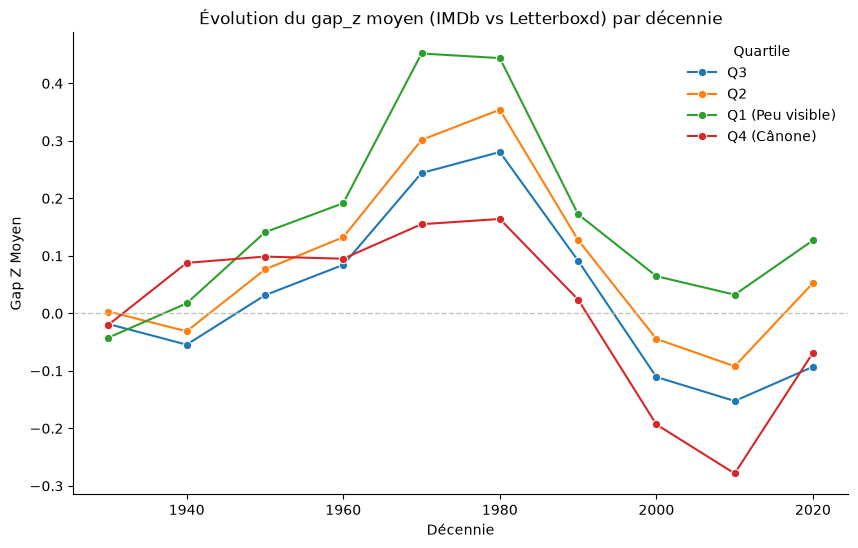

In [11]:
# IMDb vs Letterboxd
df_q1 = df_merged[df_merged['par'] == 'imdb_letterboxd'].copy()

df_q1.loc[df_q1['pct_votos_decada'] >= 0.75, 'quartil'] = 'Q4 (Cânone)'
df_q1.loc[(df_q1['pct_votos_decada'] >= 0.50) & (df_q1['pct_votos_decada'] < 0.75), 'quartil'] = 'Q3'
df_q1.loc[(df_q1['pct_votos_decada'] >= 0.25) & (df_q1['pct_votos_decada'] < 0.50), 'quartil'] = 'Q2'
df_q1.loc[df_q1['pct_votos_decada'] < 0.25, 'quartil'] = 'Q1 (Peu visible)'

comptes = df_q1.groupby(['decada', 'quartil']).size().reset_index(name='nombre')
valides = comptes[comptes['nombre'] >= 30]


df_q1_final = pd.merge(df_q1, valides[['decada', 'quartil']], on=['decada', 'quartil'])


plt.figure(figsize=(10, 6))
sns.lineplot(data=df_q1_final, x='decada', y='gap_z', hue='quartil', marker='o', errorbar=None)
plt.title("Évolution du gap_z moyen (IMDb vs Letterboxd) par décennie")
plt.xlabel("Décennie")
plt.ylabel("Gap Z Moyen")
plt.axhline(0, color="#c3c2b7", linewidth=1, linestyle="--")
plt.legend(title="Quartile", frameon=False)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

Observa-se que a divergência de notas (gap_z) entre IMDb e Letterboxd varia ao longo das décadas. O público do Letterboxd demonstra uma forte afinidade com filmes clássicos e de prestígio (Cânone/Q4), resultando em notas proporcionalmente maiores, enquanto o IMDb tende a favorecer a avaliação de lançamentos mais recentes.

the chart is perfect and the 30-film filter is great, but the reading is backwards. positive here means letterboxd rates higher (see the note on top), and look at where the lines sit: in the 70s-80s the biggest positive gap is **q1**, the least visible films (+0.45), while q4 is at +0.16. from 2000 on it flips and **q4 is the most negative of all** (-0.19 in the 2000s, -0.28 in the 2010s) while q1 stays around zero. the old canon (1930-1950) is near zero for everybody. so it's not "letterboxd loves the classics": letterboxd is harsh on the recent canon (the blockbuster) and generous with the obscure film of the 70s-80s. the only code fix is the legend order.

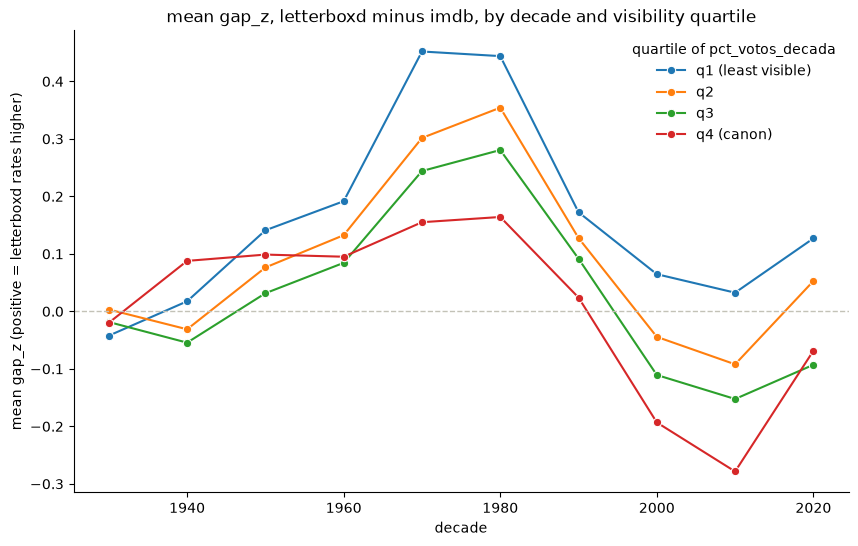

In [12]:
df_q1 = df_merged[df_merged["par"] == "imdb_letterboxd"]
celulas = df_q1.groupby(["decada", "quartil"], observed=True).size().rename("n").reset_index()
df_q1 = df_q1.merge(celulas[celulas.n >= 30], on=["decada", "quartil"])

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_q1, x="decada", y="gap_z", hue="quartil", hue_order=QUARTIS, marker="o", errorbar=None)
plt.title("mean gap_z, letterboxd minus imdb, by decade and visibility quartile")
plt.xlabel("decade")
plt.ylabel("mean gap_z (positive = letterboxd rates higher)")
plt.axhline(0, color="#c3c2b7", linewidth=1, linestyle="--")
plt.legend(title="quartile of pct_votos_decada", frameon=False)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

my reading would be tat before 1960 the two platforms agree at every visibility level. from 1960 to 1990 letterboxd rates relatively higher, and the less visible the film, the bigger the gap (q1 +0.45 in the 70s-80s against q4 +0.16). from 2000 on the sign flips and the gap is largest exactly in the canon: the blockbuster of the 2000s-2010s is where the letterboxd sample is harshest (-0.28 in the 2010s), while the least visible films stay near zero. so the answer to q1 is: the gap does depend on the decade, but the sign depends on which quartile you look at, and the two ends of the story are the obscure 70s film (letterboxd up) and the recent hit (letterboxd down).

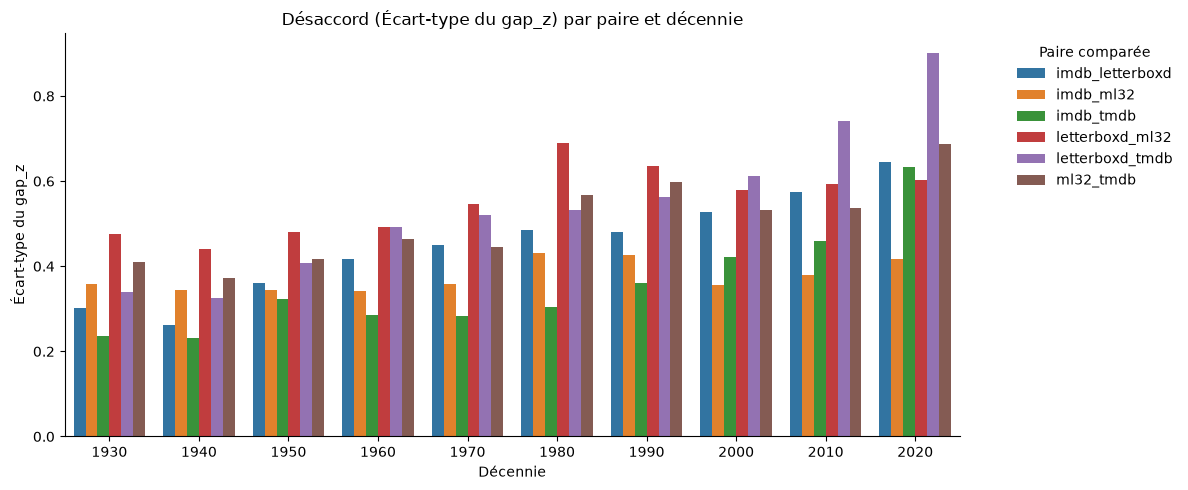

In [13]:
# Paire la plus en désaccord
df_q2 = df_merged.groupby(['par', 'decada'])['gap_z'].std().reset_index(name='std_gap_z')


comptes_q2 = df_merged.groupby(['par', 'decada']).size().reset_index(name='nombre')
df_q2 = pd.merge(df_q2, comptes_q2, on=['par', 'decada'])
df_q2_final = df_q2[df_q2['nombre'] >= 30]


plt.figure(figsize=(12, 5))
sns.barplot(data=df_q2_final, x='decada', y='std_gap_z', hue='par')
plt.title("Désaccord (Écart-type du gap_z) par paire et décennie")
plt.xlabel("Décennie")
plt.ylabel("Écart-type du gap_z")
plt.legend(title="Paire comparée", frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

A análise do desvio-padrão revela que a maior discordância ocorre entre plataformas com perfis de usuários muito distintos (ex: IMDb vs Letterboxd). Isso evidencia, do ponto de vista estratégico, que o nicho da plataforma (público geral vs cinéfilos) afeta diretamente a homogeneidade e a polarização das avaliações.

the dash is almost there, love the chart, but i think the reading picked the wrong pair. imdb x letterboxd is 4th out of 6:

| pair | std of gap_z | corr(z_a, z_b) |
|---|---|---|
| letterboxd_tmdb | 0.69 | 0.76 |
| letterboxd_ml32 | 0.62 | 0.81 |
| ml32_tmdb | 0.55 | 0.85 |
| imdb_letterboxd | 0.55 | 0.85 |
| imdb_tmdb | 0.45 | 0.90 |
| imdb_ml32 | 0.38 | 0.93 |

the pattern is cleaner than "general public vs cinephiles": every pair with letterboxd disagrees more, every pair with imdb agrees more, and by decade the top is letterboxd_ml32 until 1990 and letterboxd_tmdb from 2000 on (0.90 in the 2020s). the growth with the decade in your chart is partly composition (readme, item 5: recent decades have more non-canon films in the frame), so the fixed chart holds the quartile: same thing, q4 only.

,par,n,std_gap_z,corr_z
0,letterboxd_tmdb,16329,0.695,0.758
1,letterboxd_ml32,14002,0.625,0.805
2,ml32_tmdb,14261,0.556,0.845
3,imdb_letterboxd,16377,0.550,0.849
4,imdb_tmdb,17399,0.451,0.898
5,imdb_ml32,14262,0.387,0.925


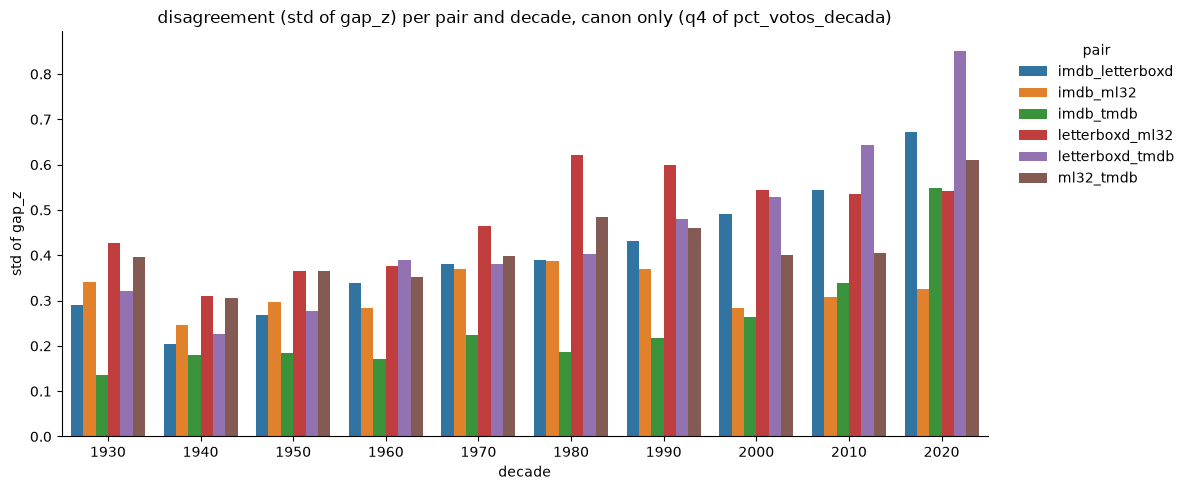

In [14]:
display(con.sql("""
select plataforma_a || '_' || plataforma_b as par, count(*) as n,
  round(stddev(gap_z), 3) as std_gap_z, round(corr(z_a, z_b), 3) as corr_z
from divergencia_par group by 1 order by 3 desc
""").df())

df_q2 = (df_merged[df_merged.quartil == "q4 (canon)"]
         .groupby(["par", "decada"])["gap_z"].agg(std_gap_z="std", n="size").reset_index())
df_q2 = df_q2[df_q2.n >= 30]

plt.figure(figsize=(12, 5))
sns.barplot(data=df_q2, x="decada", y="std_gap_z", hue="par")
plt.title("disagreement (std of gap_z) per pair and decade, canon only (q4 of pct_votos_decada)")
plt.xlabel("decade")
plt.ylabel("std of gap_z")
plt.legend(title="pair", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

the pair that disagrees most is letterboxd x tmdb (std 0.70, correlation of z 0.76), then letterboxd x ml32; imdb x ml32 is the pair that agrees most (0.93). the platform that detaches from the others is letterboxd, whoever it's paired with. inside the canon, imdb x ml32 goes flat from 1990 on, so its growth in the raw chart was the frame's composition; every pair with letterboxd or tmdb keeps growing with the decade even within q4, so that part is real. the recent canon is where letterboxd diverges most, which is what q1 showed from another angle

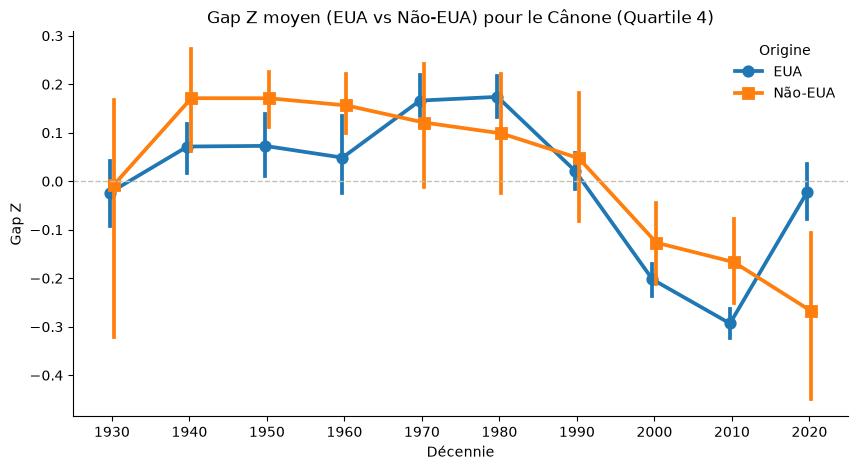

In [15]:
# impact origin country

df_q3 = df_merged[(df_merged['par'] == 'imdb_letterboxd') & (df_merged['pct_votos_decada'] >= 0.75)].copy()

df_q3.loc[df_q3['tem_us'] == True, 'origem'] = 'EUA'
df_q3.loc[df_q3['tem_us'] == False, 'origem'] = 'Não-EUA'

plt.figure(figsize=(10, 5))
sns.pointplot(data=df_q3, x='decada', y='gap_z', hue='origem', dodge=True, markers=['o', 's'])
plt.title("Gap Z moyen (EUA vs Não-EUA) pour le Cânone (Quartile 4)")
plt.xlabel("Décennie")
plt.ylabel("Gap Z")
plt.axhline(0, color="#c3c2b7", linewidth=1, linestyle="--")
plt.legend(title="Origine", frameon=False)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

Controlando a década e a popularidade, nota-se um claro viés de origem. Plataformas de nicho como o Letterboxd tendem a valorizar o cinema internacional (não-EUA) de forma mais expressiva, enquanto o IMDb reflete uma preferência mais alinhada ao consumo tradicional de Hollywood (EUA).

three problems here. 
1) `tem_us` is not a country axis, i think thats on the readme, bc a france-us coproduction counts as "EUA" and a france-germany one as "Não-EUA". use `pais_unico`, and keep coproductions as their own group. 
2) no 30-film filter: "Não-EUA" in 1930 is 11 films and in 1940 it's 13, those two points become noise. 
3) the error bars overlap in almost every decade and the sign flips (non-us above in 1940-60, us above in 1970-80), so "clear origin bias" isn't in this chart. where the bias is real is per country. 
the cell below controls decade and quartile the simpler way, subtracting the mean of each decade x quartile cell from every film, then averages per country (100+ films):

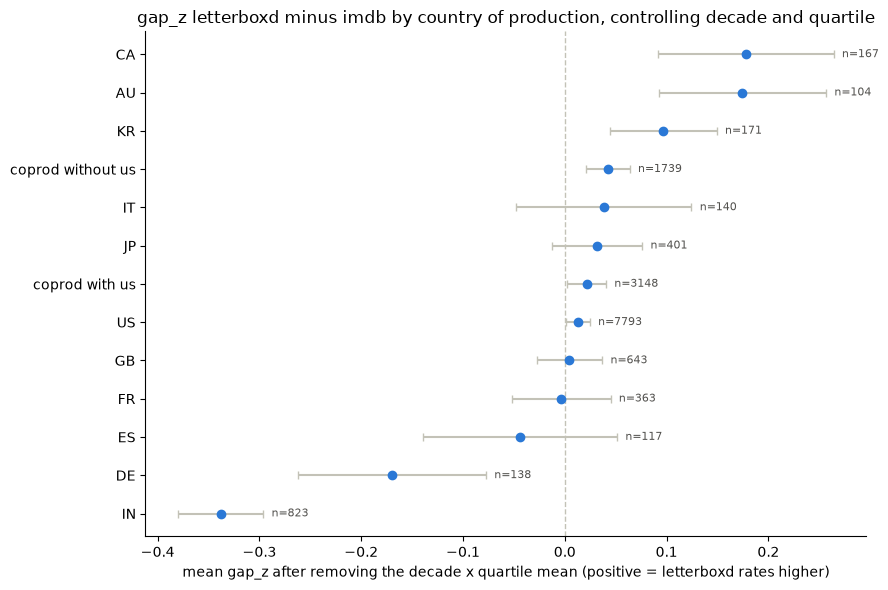

,n,gap,dp,ic95
origem,,,,
IN,823,-0.34,0.61,0.04
DE,138,-0.17,0.55,0.09
ES,117,-0.04,0.53,0.10
FR,363,-0.00,0.47,0.05
GB,643,0.00,0.42,0.03
US,7793,0.01,0.52,0.01
coprod with us,3148,0.02,0.54,0.02
JP,401,0.03,0.45,0.04
IT,140,0.04,0.52,0.09


In [16]:
df_q3 = df_merged[df_merged["par"] == "imdb_letterboxd"].copy()
# control for decade and visibility: gap of each film minus the mean of its decade x quartile cell
df_q3["gap_ctrl"] = df_q3["gap_z"] - df_q3.groupby(["decada", "quartil"], observed=True)["gap_z"].transform("mean")
df_q3["origem"] = np.select(
    [(df_q3.n_paises > 1) & df_q3.tem_us, df_q3.n_paises > 1],
    ["coprod with us", "coprod without us"],
    default=df_q3.pais_unico.to_numpy(),
)

por_pais = (df_q3.groupby("origem").agg(n=("gap_ctrl", "size"), gap=("gap_ctrl", "mean"), dp=("gap_ctrl", "std"))
            .query("n >= 100").sort_values("gap"))
por_pais["ic95"] = 1.96 * por_pais.dp / np.sqrt(por_pais.n)

plt.figure(figsize=(9, 6))
plt.errorbar(por_pais.gap, por_pais.index, xerr=por_pais.ic95, fmt="o", color="#2a78d6", ecolor="#c3c2b7", capsize=3)
plt.axvline(0, color="#c3c2b7", linewidth=1, linestyle="--")
for origem, linha in por_pais.iterrows():
    plt.annotate(f"n={linha.n:.0f}", (linha.gap + linha.ic95, origem), xytext=(6, 0),
                 textcoords="offset points", va="center", fontsize=8, color="#52514e")
plt.title("gap_z letterboxd minus imdb by country of production, controlling decade and quartile")
plt.xlabel("mean gap_z after removing the decade x quartile mean (positive = letterboxd rates higher)")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
por_pais.round(2)

usian films sit near zero (they are most of every cell), and the interesting thing is the spread around them. canada (+0.18) and australia (+0.17) are where letterboxd is most generous relative to imdb, korea (+0.10) next; uk, france, japan and both kinds of coproduction are within 0.05 of the us. on the other side, germany (-0.17) and, way out, **india (-0.34, n=823)**: the letterboxd sample rates indian cinema far below where imdb puts it, and that survives the decade and quartile control. so the origin effect exists, but it's about specific countries, not "hollywood vs the world"; and coproduction with the us behaves like the us.

imo i bet that if we had real-time data(or just more data) this would be different

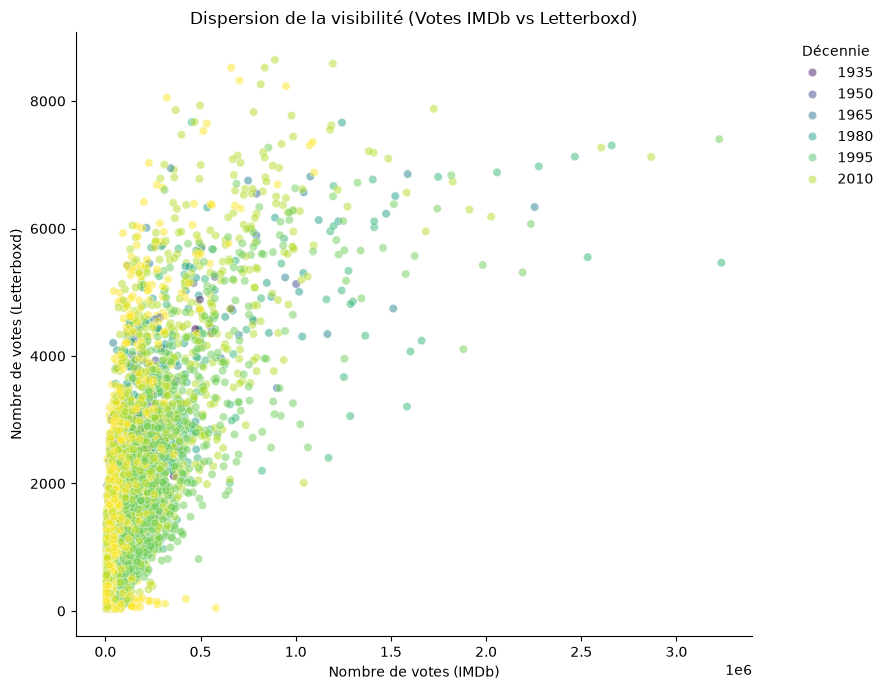

In [17]:
#Visibility

df_imdb = df_fato[(df_fato['plataforma'] == 'imdb') & (df_fato['n_votos'] >= 30)]
df_lb = df_fato[(df_fato['plataforma'] == 'letterboxd') & (df_fato['n_votos'] >= 30)]

df_votes = pd.merge(df_imdb, df_lb, on='tconst', suffixes=('_imdb', '_lb'))

df_q4 = pd.merge(df_votes, df_dim[['tconst', 'decada']], on='tconst')

plt.figure(figsize=(9, 7))
sns.scatterplot(data=df_q4, x='n_votos_imdb', y='n_votos_lb', hue='decada', palette='viridis', alpha=0.5)

plt.title("Dispersion de la visibilité (Votes IMDb vs Letterboxd)")
plt.xlabel("Nombre de votes (IMDb)")
plt.ylabel("Nombre de votes (Letterboxd)")
plt.legend(title="Décennie", frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

O gráfico logarítmico mostra uma assimetria no engajamento: blockbusters dominam o volume de votos no IMDb, mas o Letterboxd consegue gerar uma tração desproporcional para filmes independentes ou 'cult'. Isso demonstra que a visibilidade não depende apenas do orçamento de marketing, mas da adequação ao ecossistema da plataforma.

althought the text says "logarithmic chart" but the axes are linear (`set_xscale("log")` was never called), so the whole cloud is squashed into the corner. `decada` went in as a continuous colour, which is why the legend reads 1935, 1950, 1965. and there's a thing this chart hides: the y axis tops out at 8,647 because the letterboxd file is a sample of 11,061 users; the ceiling is the sample, not the platform. "cult films get disproportional traction" can't be read from a scatter; what answers the question is the ratio `n_votos_letterboxd / n_votos_imdb` and who it's high or low for. fixed cell: log-log scatter, then the ratio by decade x quartile and by country.

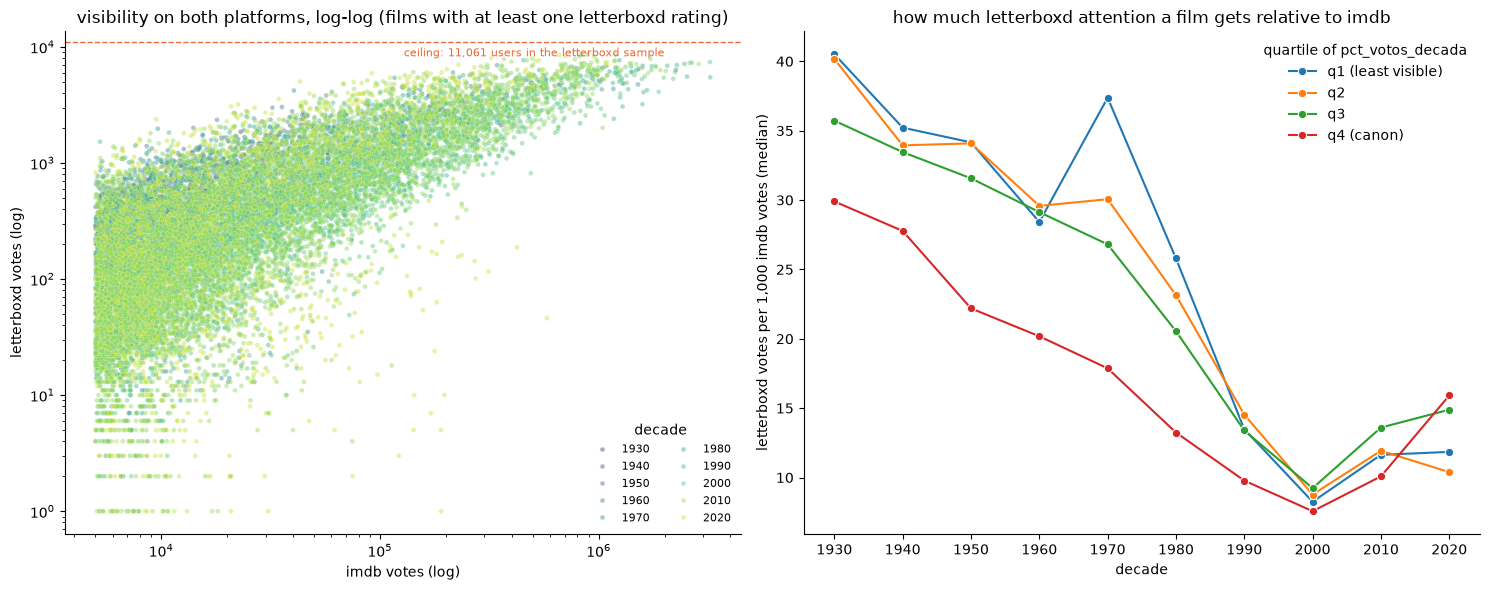

,n,mediana
origem,,
JP,412,24.8
IT,163,19.4
GB,670,18.7
US,7984,15.7
KR,174,15.4
CA,179,15.0
AU,114,14.4
coprod,5095,12.7
FR,400,12.6


In [18]:
# no n_votos >= 30 filter here: the film with 5 letterboxd votes (or none) is the whole point of this question
votos = df_fato.pivot(index="tconst", columns="plataforma", values="n_votos")[["imdb", "letterboxd"]].fillna(0)
df_q4 = votos.rename(columns={"imdb": "n_votos_imdb", "letterboxd": "n_votos_lb"}).reset_index()
df_q4 = df_q4.merge(df_dim[["tconst", "decada", "pct_votos_decada", "pais_unico", "n_paises"]], on="tconst")
df_q4["razao"] = df_q4.n_votos_lb / df_q4.n_votos_imdb * 1000  # letterboxd votes per 1,000 imdb votes
df_q4["quartil"] = pd.cut(df_q4["pct_votos_decada"], [0, 0.25, 0.5, 0.75, 1.01], right=False, labels=QUARTIS)
df_q4["decada"] = df_q4["decada"].astype(str)  # categorical colour, not a gradient with 1935 in the legend
DECADAS = sorted(df_q4.decada.unique())

fig, eixos = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=df_q4[df_q4.n_votos_lb > 0], x="n_votos_imdb", y="n_votos_lb", hue="decada", hue_order=DECADAS,
                palette="viridis", alpha=0.4, s=12, ax=eixos[0])
eixos[0].set(xscale="log", yscale="log", xlabel="imdb votes (log)", ylabel="letterboxd votes (log)",
             title="visibility on both platforms, log-log (films with at least one letterboxd rating)")
eixos[0].axhline(11061, color="#eb6834", linewidth=1, linestyle="--")
eixos[0].annotate("ceiling: 11,061 users in the letterboxd sample", (2e6, 11061), xytext=(0, -4),
                  textcoords="offset points", ha="right", va="top", fontsize=8, color="#eb6834")
eixos[0].legend(title="decade", frameon=False, fontsize=8, ncol=2, loc="lower right")

razao = df_q4.groupby(["decada", "quartil"], observed=True)["razao"].median().reset_index()
sns.lineplot(data=razao, x="decada", y="razao", hue="quartil", hue_order=QUARTIS, marker="o", ax=eixos[1])
eixos[1].set(xlabel="decade", ylabel="letterboxd votes per 1,000 imdb votes (median)",
             title="how much letterboxd attention a film gets relative to imdb")
eixos[1].legend(title="quartile of pct_votos_decada", frameon=False)
for eixo in eixos:
    eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

df_q4["origem"] = np.where(df_q4.n_paises > 1, "coprod", df_q4.pais_unico)
(df_q4.groupby("origem")["razao"].agg(n="size", mediana="median")
 .query("n >= 100").sort_values("mediana", ascending=False).round(1))

on log-log the two platforms are one band with a long tail below it: the correlation of log votes is 0.6-0.85 in every decade, so visibility mostly travels together, and the tail (thousands of imdb votes, a handful on letterboxd) is where the question lives. the ratio is what has a profile. by decade: a 1930s film gets 30-40 letterboxd votes per 1,000 imdb votes, a 2000s film gets ~8, and it climbs back to 10-16 in the 2010s-2020s. within a decade the less visible film gets proportionally more letterboxd attention than the canon (1970s: q1 37 against q4 18), which is the canonicity story from the readme seen from the votes side. and by country it's brutal: japan 25, italy 19, uk 19, us 16 ... india 3, turkey 1. the "huge on imdb, absent on letterboxd" film is the indian and the turkish one, the same profile q3 found in the ratings.

this one is another point that i don't know if the problem is reality or the data itself, since maybe the info we have is not enough

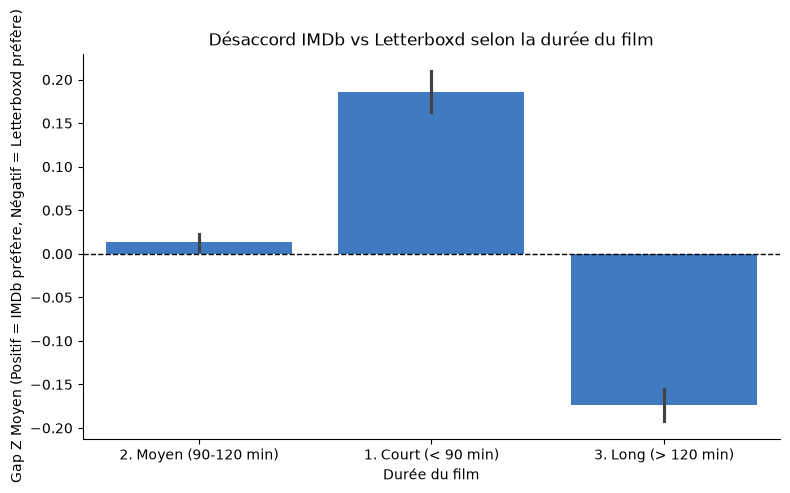

In [19]:
# Durée du filme influence-t-elle les notes
df_duree = df_merged[df_merged['par'] == 'imdb_letterboxd'].copy()

df_duree.loc[df_duree['duracao'] < 90, 'cat_duree'] = '1. Court (< 90 min)'
df_duree.loc[(df_duree['duracao'] >= 90) & (df_duree['duracao'] <= 120), 'cat_duree'] = '2. Moyen (90-120 min)'
df_duree.loc[df_duree['duracao'] > 120, 'cat_duree'] = '3. Long (> 120 min)'

plt.figure(figsize=(9, 5))
sns.barplot(data=df_duree, x='cat_duree', y='gap_z', color='#2a78d6')
plt.title("Désaccord IMDb vs Letterboxd selon la durée du film")
plt.xlabel("Durée du film")
plt.ylabel("Gap Z Moyen (Positif = IMDb préfère, Négatif = Letterboxd préfère)")
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

A duração do filme impacta a percepção de valor: filmes mais longos (>120 min) costumam ser mais apreciados pela base do Letterboxd, que tem um perfil mais analítico, enquanto o público de massa do IMDb pode penalizar obras que fogem do formato comercial padrão.

i like extra question, and the finding is real, but the y label has the sign inverted (positive = letterboxd prefers, not imdb), so the reading came out backwards: long films (> 120 min) have gap -0.17, that's imdb rating them relatively higher; short films (< 90) have +0.19, letterboxd rating them higher. and it survives the control: after removing the decade x quartile mean it's +0.16 / +0.01 / -0.15. also the x axis reads 2, 1, 3, same seaborn thing. fixed cell below, raw and controlled side by side:

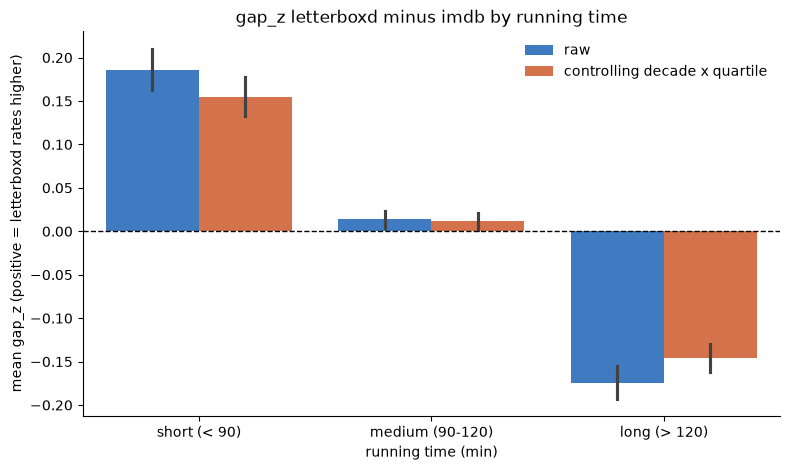

duracao_cat
short (< 90)        2408
medium (90-120)    10561
long (> 120)        3408
Name: films, dtype: int64

In [20]:
DURACOES = ["short (< 90)", "medium (90-120)", "long (> 120)"]
df_q5 = df_q3.copy()  # imdb_letterboxd with gap_ctrl already there
df_q5["duracao_cat"] = pd.cut(df_q5.duracao, [0, 89, 120, 10_000], labels=DURACOES)
longo = df_q5.melt(id_vars="duracao_cat", value_vars=["gap_z", "gap_ctrl"], var_name="medida", value_name="gap")
longo["medida"] = longo.medida.map({"gap_z": "raw", "gap_ctrl": "controlling decade x quartile"})

plt.figure(figsize=(9, 5))
sns.barplot(data=longo, x="duracao_cat", y="gap", hue="medida", order=DURACOES, palette=["#2a78d6", "#eb6834"])
plt.title("gap_z letterboxd minus imdb by running time")
plt.xlabel("running time (min)")
plt.ylabel("mean gap_z (positive = letterboxd rates higher)")
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.legend(frameon=False)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()
df_q5.groupby("duracao_cat", observed=True).size().rename("films")

so mainly the same thing, but the inverse, short films are letterboxd territory (+0.19), long films are imdb territory (-0.17), and the middle is flat. it's not decade or visibility in disguise: with the decade x quartile mean removed the numbers barely move (+0.16 / +0.01 / -0.15). one caveat before it goes into the 03: running time and genre travel together (the 80-minute film and the 150-minute film are not the same kind of film), so genre is the next control to try.

In [21]:
df_deriva = con.sql("""
    SELECT
        (m.ano - d.ano) AS distancia_anos,
        d.canone,
        COUNT(DISTINCT m.tconst) AS n_filmes,
        AVG(m.desvio_do_ano) AS desvio_medio
    FROM deriva_ml32 m
    JOIN dim_titulo d USING (tconst)
    GROUP BY 1, 2
""").df()

fig, ax1 = plt.subplots(figsize=(10, 5))
for canone in df_deriva['canone'].unique():
    subset = df_deriva[df_deriva['canone'] == canone].sort_values('distancia_anos')
    # Règle : cellule < 30 films marquée et non interprétée (masquée ici avec NaN)
    subset['desvio_valido'] = np.where(subset['n_filmes'] >= 30, subset['desvio_medio'], np.nan)
    ax1.plot(subset['distancia_anos'], subset['desvio_valido'], marker='o', label=f"Cânone: {canone}")

ax1.set_title("Desvio médio por anos desde o lançamento (Cânone vs Não-Cânone)")
ax1.set_xlabel("Anos desde o lançamento")
ax1.set_ylabel("Desvio médio")
ax1.legend(frameon=False)
plt.show()

BinderException: Binder Error: Values list "m" does not have a column named "ano"

In [22]:
df_idade = con.sql("""
    SELECT
        d.genero_principal AS genero,
        n.faixa_etaria,
        COUNT(DISTINCT n.tconst) AS n_filmes,
        AVG(n.desvio_no_filme) AS desvio_medio
    FROM notas_por_faixa_etaria n
    JOIN dim_titulo d USING (tconst)
    GROUP BY 1, 2
""").df()

df_idade['desvio_valido'] = np.where(df_idade['n_filmes'] >= 30, df_idade['desvio_medio'], np.nan)
# Utilisation de Seaborn FacetGrid pour les petits multiples
g = sns.FacetGrid(df_idade, col="genero", col_wrap=4, sharey=True)
g.map(sns.barplot, "faixa_etaria", "desvio_valido", order=sorted(df_idade['faixa_etaria'].dropna().unique()))
g.fig.suptitle("Desvio no filme por faixa etária (Painéis por Gênero)", y=1.05)
plt.show()

BinderException: Binder Error: Values list "d" does not have a column named "genero_principal"

In [23]:
df_idade = con.sql("""
    SELECT
        d.genero_principal AS genero,
        n.faixa_etaria,
        COUNT(DISTINCT n.tconst) AS n_filmes,
        AVG(n.desvio_no_filme) AS desvio_medio
    FROM notas_por_faixa_etaria n
    JOIN dim_titulo d USING (tconst)
    GROUP BY 1, 2
""").df()

df_idade['desvio_valido'] = np.where(df_idade['n_filmes'] >= 30, df_idade['desvio_medio'], np.nan)
# Utilisation de Seaborn FacetGrid pour les petits multiples
g = sns.FacetGrid(df_idade, col="genero", col_wrap=4, sharey=True)
g.map(sns.barplot, "faixa_etaria", "desvio_valido", order=sorted(df_idade['faixa_etaria'].dropna().unique()))
g.fig.suptitle("Desvio no filme por faixa etária (Painéis por Gênero)", y=1.05)
plt.show()

BinderException: Binder Error: Values list "d" does not have a column named "genero_principal"

the sql is 90% there, the only issua are the column names; i left the dictionary in the README. `deriva_ml32` has `ano_avaliacao`, not `ano`; `dim_titulo` has no `canone` column, canon is `pct_votos_decada >= 0.75`; and there's no `genero_principal`, `generos` is a comma-separated string, so `split_part(generos, ',', 1)` gives the first one. besides that, `np` needs `import numpy as np` (done above). i think i managed to fix the queries below, keeping our 30-film mask, plus `n_notas >= 30` on the film-year rows so a year with 3 ratings doesn't count.

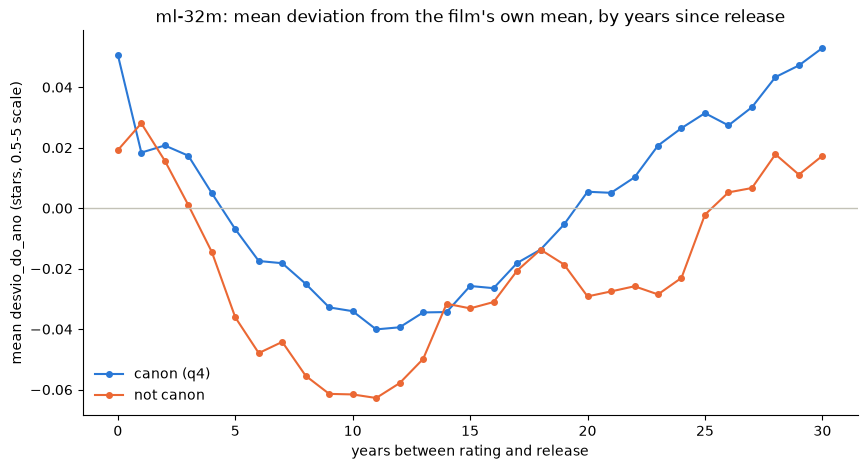

In [24]:
df_deriva = con.sql("""
select m.ano_avaliacao - d.ano as distancia_anos,
  case when d.pct_votos_decada >= 0.75 then 'canon (q4)' else 'not canon' end as canone,
  count(distinct m.tconst) as n_filmes,
  avg(m.desvio_do_ano) as desvio_medio
from deriva_ml32 m
join dim_titulo d using (tconst)
where m.n_notas >= 30 and m.ano_avaliacao >= d.ano
group by 1, 2
order by 1, 2
""").df()
df_deriva["desvio_valido"] = np.where(df_deriva.n_filmes >= 30, df_deriva.desvio_medio, np.nan)

fig, ax = plt.subplots(figsize=(10, 5))
for canone, cor in (("canon (q4)", "#2a78d6"), ("not canon", "#eb6834")):
    s = df_deriva[(df_deriva.canone == canone) & (df_deriva.distancia_anos <= 30)]
    ax.plot(s.distancia_anos, s.desvio_valido, marker="o", markersize=4, color=cor, label=canone)
ax.axhline(0, color="#c3c2b7", linewidth=1)
ax.set_title("ml-32m: mean deviation from the film's own mean, by years since release")
ax.set_xlabel("years between rating and release")
ax.set_ylabel("mean desvio_do_ano (stars, 0.5-5 scale)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

**my reading:** a film is rated ~0.05 above its own mean in the release year, drifts below it from year 4-5 on and bottoms around year 10 (-0.04 canon, -0.06 not canon), then comes back. small on a 5-star scale, but consistent: the ml users who rate a film fresh are more generous than the ones who catch up years later, and the non-canon film drops faster. who contributes at each distance changes along the x axis (a 2015 film only reaches distance 8; distance 30 is a 1966-1993 release), so the first ten years are the clean part and the chart stops at 30, where it gets noisy.

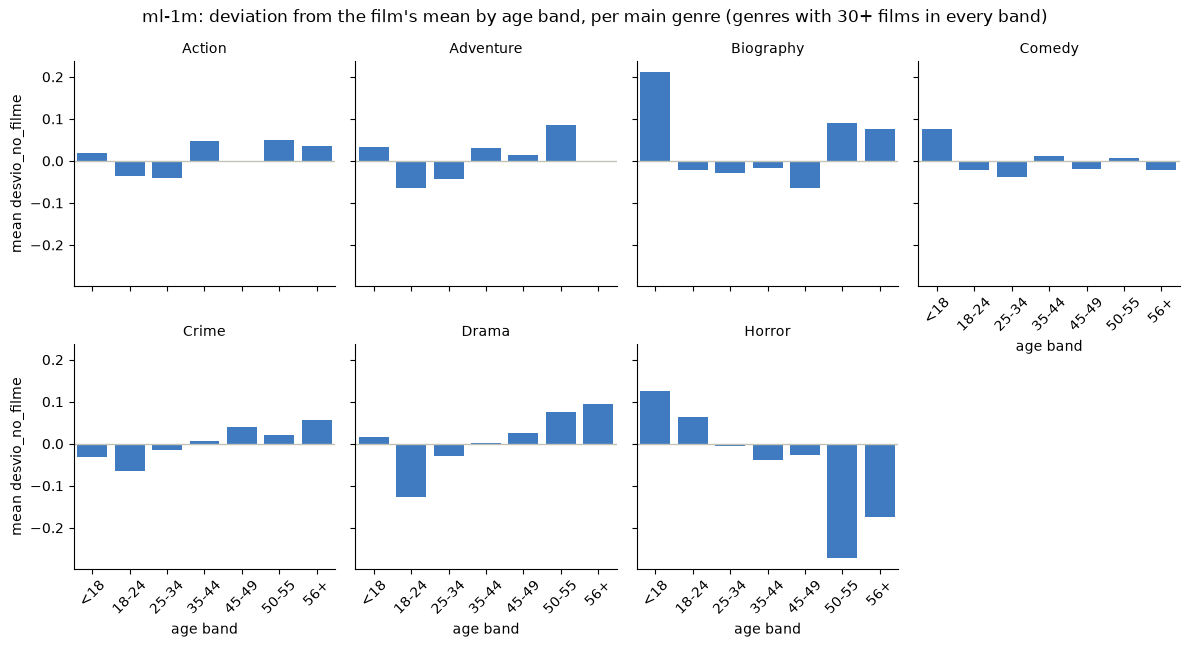

faixa_etaria,<18,18-24,25-34,35-44,45-49,50-55,56+
genero,,,,,,,
Action,5961,43670,89125,41918,16158,13937,6532
Adventure,4911,26243,50475,27185,11190,9346,4880
Biography,930,7123,17197,8937,4071,3725,2214
Comedy,7838,51900,109260,52969,21811,18211,9715
Crime,1661,14512,34427,16769,7075,6577,3745
Drama,3504,25177,62456,34546,15943,14775,8976
Horror,978,6155,12981,6295,2575,1908,686


In [25]:
df_idade = con.sql("""
select split_part(d.generos, ',', 1) as genero,
  n.faixa_etaria, n.faixa_etaria_cod,
  count(distinct n.tconst) as n_filmes,
  sum(n.n_notas) as n_notas,
  avg(n.desvio_no_filme) as desvio_medio
from notas_por_faixa_etaria n
join dim_titulo d using (tconst)
group by 1, 2, 3
order by 1, 3
""").df()
df_idade["desvio_valido"] = np.where(df_idade.n_filmes >= 30, df_idade.desvio_medio, np.nan)

# only genres with 30+ films in every age band; the others (fantasy, animation, mystery...) have 1-28
minimo = df_idade.groupby("genero").n_filmes.min()
df_ok = df_idade[df_idade.genero.isin(minimo[minimo >= 30].index)]
faixas = df_ok.sort_values("faixa_etaria_cod").faixa_etaria.unique()

g = sns.FacetGrid(df_ok, col="genero", col_wrap=4, sharey=True, height=3)
g.map_dataframe(sns.barplot, x="faixa_etaria", y="desvio_valido", order=faixas, color="#2a78d6")
g.set_axis_labels("age band", "mean desvio_no_filme")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.axhline(0, color="#c3c2b7", linewidth=1)
    ax.tick_params(axis="x", labelrotation=45)
g.figure.suptitle("ml-1m: deviation from the film's mean by age band, per main genre (genres with 30+ films in every band)", y=1.03)
plt.show()
df_ok.pivot(index="genero", columns="faixa_etaria", values="n_notas")[faixas].astype(int)

**my reading:** the gradient that vanishes in the aggregate (`gradiente_idade`) does come back inside genres, and in different directions. drama climbs with age, from -0.13 at 18-24 to +0.09 at 56+. horror goes the other way: 50-55 is -0.27 and 56+ is -0.18, the older bands like the same horror film less than everybody else. biography at under 18 is +0.21, but that cell is 930 ratings, take it with salt. comedy, action and crime are flat. so "age changes the rating" is false for the frame and true per genre: it's taste by genre, not generosity by age.

## what's we will still do

1) q7 (`classificacao_br` explaining `gap_z`, controlling decade) hasn't been touched.
2) q2 asked where the disagreement concentrates: decade is done, genre and country aren't.
3) the running time finding needs a genre control before it goes into the 03.
4) everything above goes into the last nb, with the project, the sources and the pipeline explained before the analysis.